# A kernel-checked mechanistic circuit for a learned transformer

### `Spec  ==  Circuit  ==  Model`, over a *complete* finite domain

This notebook walks through the whole artifact end to end — the trained model, the
symbolic **circuit** we extract from it, the mechanism made visual, the rigorous
**certificate** that the network *is* that circuit on every input, the Lean
**theorem** that the circuit is the spec, and exactly **what you must trust**. It
ends with how to **verify it yourself**.

> **The one-line claim.** A tiny transformer learns **Dyck-1** (balanced
> parentheses) to *exact 100%* over its entire input domain; we render its
> computation as a human-readable circuit and ship independently-checkable evidence
> that the **spec, the circuit, and the trained model all coincide on every input** —
> with a kernel-checked proof of the circuit↔spec half.

*Everything below is executed and saved with outputs inline — you can read it
without running anything, or re-run the light path (see the last section).*

## 1. The problem, and the ownable gap

**Dyck-1.** Tokens `(`=0, `)`=1. A string is *valid* iff its running depth never
goes negative and ends at 0 — so it genuinely needs the **order** check, not just a
count of parentheses. The valid strings of length $n$ are counted by the Catalan
numbers.

**The gap we target.** Recent work pairs interpretability with formal guarantees —
Gross, Agrawal et al. (NeurIPS 2024) prove compact *performance lower bounds*;
Hadad, Katz, Bassan (2026) certify circuit *robustness/minimality*. Neither ships a
**kernel-checked circuit-to-spec _equivalence_ for a learned algorithm over the
whole finite domain**, as a reproducible artifact. That total
`Spec == Circuit == Model` is what this repo owns. (The trade, stated plainly: we
buy *guarantee strength* with *task simplicity* — see `docs/FAQ.md`.)

In [1]:
%matplotlib inline
import os, sys, json, math, subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt

from vcirc import dyck
from vcirc.circuit import Circuit
from vcirc.certify import load_model

torch.set_grad_enabled(False)

# the deployed, exact n=10 model (committed for reproducibility)
model = load_model("models/dyck10_exact_seed0.pt")
cfg = model.cfg
print("TinyTransformer config:", cfg)
print("(causal attention, 2 layers, sum-pool, MLP readout, NO LayerNorm)")

TinyTransformer config: {'n': 10, 'd': 32, 'heads': 2, 'ff': 64, 'layers': 2, 'causal': True, 'pool': 'sum'}
(causal attention, 2 layers, sum-pool, MLP readout, NO LayerNorm)


## 2. The trained model

A deliberately transparent `TinyTransformer`: token+position embeddings →
**causal** attention → ReLU MLP (×2 layers) → **sum-pool** → MLP readout → 2
logits. No LayerNorm, so the weights stay exact dyadic rationals for the later
rigorous re-evaluation. It is trained only on the Dyck-1 label, then evaluated on
the **entire** domain.

In [2]:
def classify(s):
    logit = model(torch.tensor([s]))[0]
    gap = float(logit[1] - logit[0])           # >0 => predicts valid
    return int(logit.argmax()), gap

examples = [
    (0,0,1,1,0,0,1,1,0,1),   # (())(())()   balanced, well-ordered  -> valid
    (0,1,0,1,0,1,0,1,0,1),   # ()()()()()   balanced, well-ordered  -> valid
    (1,0,1,0,1,0,1,0,1,0),   # )()()()()(   balanced COUNT, order violated -> invalid
    (0,0,1,1,1,0,0,1,1,0),   # depth dips / ends nonzero            -> invalid
]
print(f"{'string':<12}  {'model':<8}{'spec':<8}{'margin':>9}")
for s in examples:
    pred, gap = classify(s)
    txt = "".join("(" if t == 0 else ")" for t in s)
    print(f"{txt:<12}  {('valid' if pred else 'invalid'):<8}"
          f"{('valid' if dyck.is_valid(s) else 'invalid'):<8}{gap:+9.3f}")

string        model   spec       margin
(())(())()    valid   valid      +9.846
()()()()()    valid   valid      +9.184
)()()()()(    invalid invalid  -129.705
(()))(())(    invalid invalid   -30.632


In [3]:
# exact over the FULL n=10 domain (1,024 inputs); n=16 referenced from its cert
strings10 = list(dyck.enumerate_all(10))
X10 = torch.tensor(strings10)
logits10 = model(X10)
pred10 = logits10.argmax(1).numpy()
truth10 = np.array([1 if dyck.is_valid(s) else 0 for s in strings10])
correct = int((pred10 == truth10).sum())
gaps = (logits10.gather(1, torch.tensor(truth10)[:, None]).squeeze(1)
        - logits10.gather(1, torch.tensor(1 - truth10)[:, None]).squeeze(1))
print(f"n=10 FULL domain: {correct}/{len(X10)} correct = {100*correct/len(X10):.4f}%  "
      f"| min decision margin {gaps.min():+.4f}  | #valid {int(truth10.sum())} = Catalan(5)")

c16 = json.load(open("certificates/dyck16_exact_seed0.v2.cert.json"))
print(f"\nn=16 (committed certificate, NOT recomputed here):")
print(f"  domain {c16['domain_size']:,} | argmax==circuit on all: "
      f"{c16['argmax_equals_circuit_all_inputs']} | rigorous min margin >= "
      f"{c16['min_margin_lower_bound']['float']:+.6f}")

n=10 FULL domain: 1024/1024 correct = 100.0000%  | min decision margin +6.3957  | #valid 42 = Catalan(5)

n=16 (committed certificate, NOT recomputed here):
  domain 65,536 | argmax==circuit on all: True | rigorous min margin >= +8.095074


## 3. The extracted circuit

The architecture was *designed* for an inductive bias, and the probes (next
section) confirm the model uses it. The extracted circuit (`vcirc/circuit.py`):

```
                token  (=+1  )=-1
                  │
   causal attn → running prefix depth     d_i            ┐
                  │                                       │  per position
   per-pos MLP → violation flag           v_i = [d_i<0]  ┘
                  │
   sum-pool    → final_depth = d_n ,  violation_count = Σ v_i
                  │
   readout MLP → valid  :=  (final_depth == 0) AND (violation_count == 0)
```

Because `violation_count == 0  ⇔  no prefix went negative`, this is *exactly* the
Dyck-1 test. Here it is running on the order-violated example — balanced **count**,
but invalid because a prefix dips below zero:

In [4]:
s = (1,0,1,0,1,0,1,0,1,0)   # )()()()()(  -- 5 of each, but starts with ')'
tr = Circuit.trace(s)
print("input        :", "".join("(" if t == 0 else ")" for t in s))
print("depths   d_i :", list(tr.depths))
print("violations v :", list(tr.violations), " (1 where d_i < 0)")
print("final_depth  :", tr.final_depth, "  (balanced count -- 5 '(' and 5 ')')")
print("violation_cnt:", tr.violation_count, "  (but the order is violated)")
print("decision     :", "VALID" if tr.valid else "INVALID")
assert tr.valid == dyck.is_valid(s)  # circuit == spec, by construction

input        : )()()()()(
depths   d_i : [-1, 0, -1, 0, -1, 0, -1, 0, -1, 0]
violations v : [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]  (1 where d_i < 0)
final_depth  : 0   (balanced count -- 5 '(' and 5 ')')
violation_cnt: 5   (but the order is violated)
decision     : INVALID


## 4. The mechanism, made visual

Three pictures, all over the full domain, showing the model *implements* the
circuit (not just reproduces its output).

**(a) Causal attention = read your prefix.** Each position can only attend to
positions $\le i$ — the substrate for a running prefix statistic.

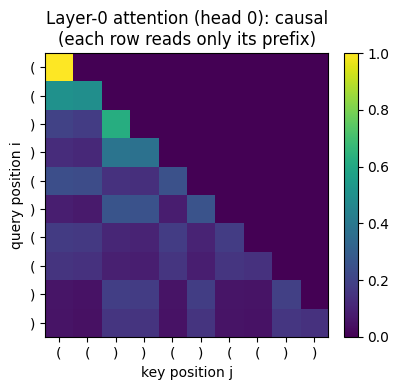

In [5]:
s = (0,0,1,1,0,1,0,0,1,1)
x = torch.tensor([s])
z = model.tok(x) + model.pos[None, :, :]
blk = model.blocks[0]
d, h = cfg["d"], cfg["heads"]; dh = d // h
q = blk.Wq(z).view(1, cfg["n"], h, dh).transpose(1, 2)
k = blk.Wk(z).view(1, cfg["n"], h, dh).transpose(1, 2)
att = (q @ k.transpose(-1, -2)) / math.sqrt(dh)
att = att.masked_fill(torch.triu(torch.ones(cfg["n"], cfg["n"]), 1).bool(),
                      float("-inf")).softmax(-1)
toks = ["(" if t == 0 else ")" for t in s]
fig, ax = plt.subplots(figsize=(4.6, 4.0))
im = ax.imshow(att[0, 0].numpy(), cmap="viridis")
ax.set_title("Layer-0 attention (head 0): causal\n(each row reads only its prefix)")
ax.set_xlabel("key position j"); ax.set_ylabel("query position i")
ax.set_xticks(range(len(s))); ax.set_xticklabels(toks)
ax.set_yticks(range(len(s))); ax.set_yticklabels(toks)
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

**(b) The residual stream encodes the running depth.** A *per-position* linear
probe recovers the prefix depth $d_i$ almost exactly — the model really is
computing the prefix sum. (The encoding direction is position-dependent, so a
single shared direction does worse; this matches the A2a probes.)

prefix depth decodable PER POSITION: mean R^2 = 0.9998 (min 0.9994) -- the model computes the prefix sum
(one shared direction across positions: R^2 = 0.778 -- the encoding is position-dependent)


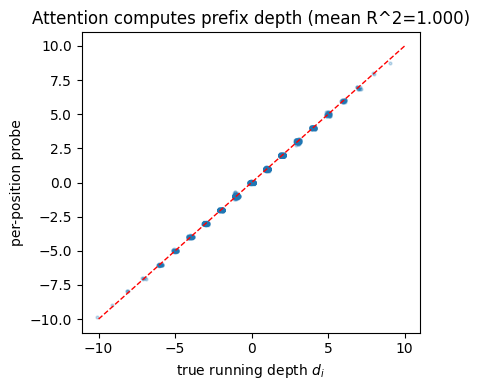

In [6]:
from sklearn.linear_model import LinearRegression
z1 = model.blocks[0](model.tok(X10) + model.pos[None, :, :], model.causal)  # (N, n, d) after block 0
Dall = np.array([d for s in strings10 for d in dyck.depth_profile(s)])
r2s, T, P = [], [], []
for i in range(cfg["n"]):
    Zi = z1[:, i, :].numpy()
    Di = np.array([dyck.depth_profile(s)[i] for s in strings10])
    reg = LinearRegression().fit(Zi, Di)
    r2s.append(reg.score(Zi, Di)); T.append(Di); P.append(reg.predict(Zi))
shared_r2 = LinearRegression().fit(z1.reshape(-1, cfg["d"]).numpy(), Dall).score(
    z1.reshape(-1, cfg["d"]).numpy(), Dall)
print(f"prefix depth decodable PER POSITION: mean R^2 = {np.mean(r2s):.4f} "
      f"(min {min(r2s):.4f}) -- the model computes the prefix sum")
print(f"(one shared direction across positions: R^2 = {shared_r2:.3f} "
      f"-- the encoding is position-dependent)")
T = np.concatenate(T); P = np.concatenate(P)
rng = np.random.RandomState(0); idx = rng.choice(len(T), 2500, replace=False)
fig, ax = plt.subplots(figsize=(4.4, 4.0))
ax.scatter(T[idx] + rng.uniform(-.15, .15, idx.size), P[idx], s=4, alpha=.25)
ax.plot([T.min(), T.max()], [T.min(), T.max()], "r--", lw=1)
ax.set_xlabel("true running depth $d_i$"); ax.set_ylabel("per-position probe")
ax.set_title(f"Attention computes prefix depth (mean R^2={np.mean(r2s):.3f})")
plt.tight_layout(); plt.show()

**(c) The readout fires "valid" in exactly one cell.** Plotting the model's
decision against the two pooled aggregates $(\text{final\_depth},
\text{violation\_count})$: it predicts *valid* **only** at $(0, 0)$ — the
non-monotone "both aggregates are zero" test.

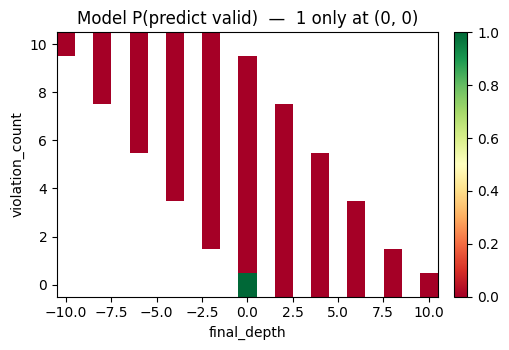

model predicts VALID only at (final_depth, violation_count) = [(0, 0)]


In [7]:
fd = np.array([Circuit.trace(s).final_depth for s in strings10])
vc = np.array([Circuit.trace(s).violation_count for s in strings10])
mdec = pred10
fds = list(range(fd.min(), fd.max() + 1)); vcs = list(range(0, vc.max() + 1))
grid = np.full((len(vcs), len(fds)), np.nan)
for i, vv in enumerate(vcs):
    for j, ff in enumerate(fds):
        m = (fd == ff) & (vc == vv)
        if m.any(): grid[i, j] = mdec[m].mean()
fig, ax = plt.subplots(figsize=(5.2, 3.6))
im = ax.imshow(grid, origin="lower", cmap="RdYlGn", vmin=0, vmax=1, aspect="auto",
               extent=[fds[0]-.5, fds[-1]+.5, vcs[0]-.5, vcs[-1]+.5])
ax.set_xlabel("final_depth"); ax.set_ylabel("violation_count")
ax.set_title("Model P(predict valid)  —  1 only at (0, 0)")
fig.colorbar(im, fraction=0.035, pad=0.04); plt.tight_layout(); plt.show()
print("model predicts VALID only at (final_depth, violation_count) =",
      sorted(set(zip(fd[mdec == 1].tolist(), vc[mdec == 1].tolist()))))

## 5. The certificate in action — `Circuit == Model`

The substantive empirical claim: the **trained network's argmax equals the
circuit on every input, with a strictly positive margin** — proven by *rigorous
interval arithmetic* on the exact-real function the weights define, and
re-checkable **torch-free**. Below, the standalone re-checker runs live on the
n=10 certificate (single-threaded, trivially auditable; trusts only the Python
stdlib + the ~390-line `vcirc/exact.py`).

In [8]:
out = subprocess.run(
    [sys.executable, "certificates/check.py", "certificates/dyck10_exact_seed0.v2.cert.json"],
    cwd=".", capture_output=True, text=True)
print(out.stdout.strip())
if out.returncode != 0:
    print("STDERR:", out.stderr[-1000:])

[1/4] weights export hash OK (1336779794759371...)
[2/4] reconstructed exact weights (n=10, d=32, scale 1/sqrt(dh)=1/4)
[3/4] circuit re-derived + margins recomputed on all 1024 inputs
[4/4] every margin lower bound > 0; min = +6.395669 at 0001011110 (max endpoint bits 105)

VERIFIED: 'the exact-real function defined by these weights has argmax == Circuit...'
  domain 1024  precision 96 bits  rigorous min margin >= +6.395669


In [9]:
# n=16 is identical in kind but ~hours to re-run, so we reference its committed
# certificate rather than recompute it here.
keys = ["n", "domain_size", "rung", "argmax_equals_circuit_all_inputs",
        "interval_precision_bits", "max_endpoint_bits"]
print("n=16 certificate (committed; reproduce with: python certificates/check.py "
      "certificates/dyck16_exact_seed0.v2.cert.json --jobs=8):")
print(json.dumps({k: c16[k] for k in keys}, indent=2))
mm = c16["min_margin_lower_bound"]
print(f"rigorous min margin lower bound = {mm['fraction'][0]} / {mm['fraction'][1]} "
      f"= {mm['float']:+.6f}  on all {c16['domain_size']:,} inputs")

n=16 certificate (committed; reproduce with: python certificates/check.py certificates/dyck16_exact_seed0.v2.cert.json --jobs=8):
{
  "n": 16,
  "domain_size": 65536,
  "rung": "v2-exact",
  "argmax_equals_circuit_all_inputs": true,
  "interval_precision_bits": 96,
  "max_endpoint_bits": 108
}
rigorous min margin lower bound = 320678931157985547263444506219 / 39614081257132168796771975168 = +8.095074  on all 65,536 inputs


## 6. The theorem — `Circuit == Spec` (kernel-checked)

The other half is a Lean 4 theorem, proved by **structural induction over the
input — not enumeration** — so it holds for *every* length (n=16 and beyond) at
once. The build also re-checks the faithfulness cross-checks and prints the axiom
audit. `lake build` runs live below (seconds).

In [10]:
import re
src = open("proofs/VerifiedCircuits/Equiv.lean").read()
thm = src[src.index("theorem circuit_eq_spec"):]
print(thm[:thm.index(":= by")].strip(), ":= by  -- (structural induction)\n")

env = dict(os.environ); env["PATH"] = os.path.expanduser("~/.elan/bin") + ":" + env["PATH"]
out = subprocess.run(["lake", "build"], cwd="proofs", capture_output=True, text=True, env=env)
tail = (out.stdout + out.stderr).strip().splitlines()
for line in tail[-6:]:
    print(line)

theorem circuit_eq_spec (s : List Tok) : Circuit.valid s = Spec.isValid s := by  -- (structural induction)



ℹ [6/7] Replayed VerifiedCircuits
info: VerifiedCircuits.lean:35:0: [1, 0, 1, 0, 2, 0, 5, 0, 14, 0, 42]
info: VerifiedCircuits.lean:40:0: true
info: VerifiedCircuits.lean:45:0: 'VerifiedCircuits.circuit_eq_spec' depends on axioms: [propext, Quot.sound]
Build completed successfully (7 jobs).


## 7. What must you trust? — three links, three trust levels

The end-to-end claim is **three links at three different trust levels**.
"Kernel-checked" applies to exactly one of them — we name all three so a skeptic
doesn't have to ask.

| Link | How | Trust level | Scope |
|---|---|---|---|
| `Circuit == Spec` | Lean 4 theorem, by induction | **kernel-proven** (Lean kernel + `propext`, `Quot.sound`) | **all lengths** |
| `Circuit == Model` | rigorous interval-arithmetic certificate | machine-checked rational bound (stdlib + ~390-line core) | per-input, n=10 & **n=16** |
| Lean/Python ↔ same algorithm | faithful transcription | **corroborated, not proven** | binary `{(, )}` alphabet |

The interval certificate's soundness is **analytic** (every op rounds *outward* →
a rigorous enclosure by construction). The transcription link is the one
unavoidable soft seam — corroborated (the Lean spec reproduces the **Catalan
numbers**, so it is pinned to what Dyck-1 *mathematically is*; circuit == spec on
all short strings; an independent line-by-line audit), not proved, because Python
is not a formal object. Full treatment: [`docs/FAQ.md`](docs/FAQ.md).

## 8. Verify it yourself

```bash
# Circuit == Spec   — trust: the Lean kernel (Lean core only, no Mathlib; seconds)
cd proofs && lake build

# Circuit == Model  — trust: Python stdlib + vcirc/exact.py (no torch)
python certificates/check.py certificates/dyck10_exact_seed0.v2.cert.json          # ~minutes
python certificates/check.py certificates/dyck16_exact_seed0.v2.cert.json --jobs=8 # ~hours
```

The re-checker re-derives the circuit independently, recomputes every rigorous
margin from the weight export alone, and confirms the pinned hash. The Lean build
re-checks the theorem from the kernel up.

That's the whole artifact: a learned transformer, rendered as a circuit, proved
equal to its spec and certified equal to its weights — **`Spec == Circuit ==
Model`, over every input, checkable without trusting our Python.**